In [17]:
import pandas as pd

In [18]:
df = pd.read_csv("../data/final_table.csv")

df["order"] = df["taxonomy"].apply(
    lambda x: [t for t in x.split(";") if t.startswith("o__")][0].replace("o__", "")
)

candidates_df = pd.read_csv('../data/clusters_candidates.csv')

In [19]:
color_map = {
    'sulfo- ASMO': '#d67769',
    'sulfo-ED': '#ffd700',
    'sulfo-EMP': "#2CAEA1",
    'sulfo-TAL': '#df81b5',
    'sulfo-TK': '#993399'
}

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from BCBio import GFF
from dna_features_viewer import BiopythonTranslator
import warnings

class ColorTranslator(BiopythonTranslator):
    def __init__(self, candidates_df, path_color='green'):
        super().__init__()
        self.mapping = {str(t).strip(): str(g).strip() for t, g in zip(candidates_df['target'], candidates_df['Gene'])}
        self.path_color = path_color

    def _get_gff_id(self, feature):
        quals = feature.qualifiers
        tags = quals.get('locus_tag') or quals.get('ID') or []
        return str(tags[0]).strip() if tags else ""

    def compute_feature_color(self, feature):
        gff_id = self._get_gff_id(feature)
        if not gff_id:
            return 'lightgray'
            
        for target in self.mapping.keys():
            if gff_id == target or gff_id in target or target in gff_id:
                return self.path_color
                
        return 'lightgray'

    def compute_feature_label(self, feature):
        gff_id = self._get_gff_id(feature)
        if not gff_id:
            return ""

        for target, gene in self.mapping.items():
            if gff_id == target or gff_id in target or target in gff_id:
                return gene
        return ""

def extract_ids(s):
    parts = str(s).split(',')
    ids = [part.split('.')[-1] for part in parts]
    clean_ids = [id_str.split('_', 1)[1] if '_' in id_str and id_str[0].isdigit() else id_str for id_str in ids]
    return clean_ids

def visualize_path(gff_path, cluster_number, df_clusters, candidates_df, pathway=None, color_map=None, genome_id=None):
    color_map = color_map or {}

    df_filtered = df_clusters[df_clusters['cluster'] == cluster_number].copy()
    if df_filtered.empty:
        print(f"{cluster_number} not found")
        return
        
    df_filtered['target_ids'] = df_filtered['target'].apply(extract_ids)
    gene_path_list = df_filtered['target_ids'].explode().dropna().astype(str).str.strip().tolist()
    
    if not gene_path_list:
        print(f"Genes for {cluster_number} not found")
        return

    chosen_color = color_map.get(pathway, 'green') if pathway else 'green'
    
    with open(gff_path) as in_handle:
        for record in GFF.parse(in_handle):
            record.features = [f for f in record.features if f.type not in ['region', 'source', 'chromosome']]

            def get_feat_id(f):
                quals = f.qualifiers
                tags = quals.get('locus_tag') or quals.get('ID')
                return str(tags[0]).strip() if tags else None

            feats = {get_feat_id(f): f for f in record.features if get_feat_id(f) is not None}

            if not all(gene in feats for gene in gene_path_list):
                continue

            all_feats = record.features
            idx_start = max(0, all_feats.index(feats[gene_path_list[0]]))
            idx_end = min(len(all_feats), all_feats.index(feats[gene_path_list[-1]]) + 1)
            selected = all_feats[idx_start:idx_end]
            
            start_pos = int(min(f.location.start for f in selected))
            end_pos = int(max(f.location.end for f in selected))

            translator = ColorTranslator(candidates_df, path_color=chosen_color)
            graphic_record = translator.translate_record(record)
            cropped_record = graphic_record.crop((start_pos, end_pos))

            with warnings.catch_warnings():
                warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*divide by zero.*')
                ax, _ = cropped_record.plot(figure_width=14, strand_in_label_threshold=7)
                
            ax.set_title(f"{pathway} in {genome_id}", loc='center')

            plt.savefig(f'../pictures/loci_landscape/{genome_id}_{pathway}.png', dpi=300, bbox_inches='tight')
            plt.show()
            return

### Sulfo-EMP

In [25]:
df_emp = df[(df["SQ_score"] == "max") & (df["SQ_pathway"] == "sulfo-EMP")].copy()

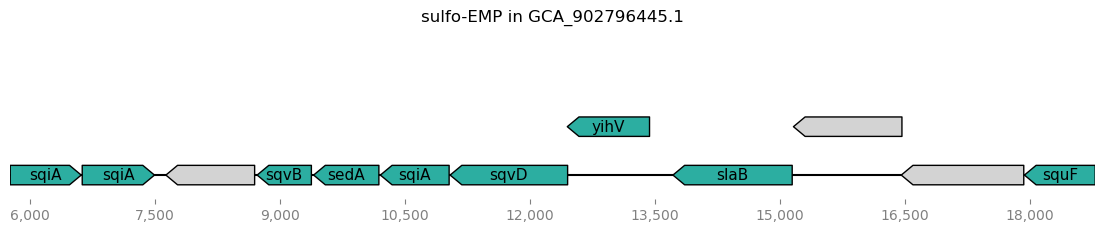

In [26]:
input_file = "../data/bakta_annotations/GCA_902796445.1_annot/GCA_902796445.1.gff3"
cluster_number = 31196
visualize_path(input_file, cluster_number, df_clusters=df_emp, candidates_df=candidates_df,
               pathway='sulfo-EMP', color_map= color_map, genome_id='GCA_902796445.1')

### Sulfo-TAL

In [27]:
df_tal = df[(df["SQ_score"].isin(["max"])) & (df["SQ_pathway"] == "sulfo-TAL")].copy()

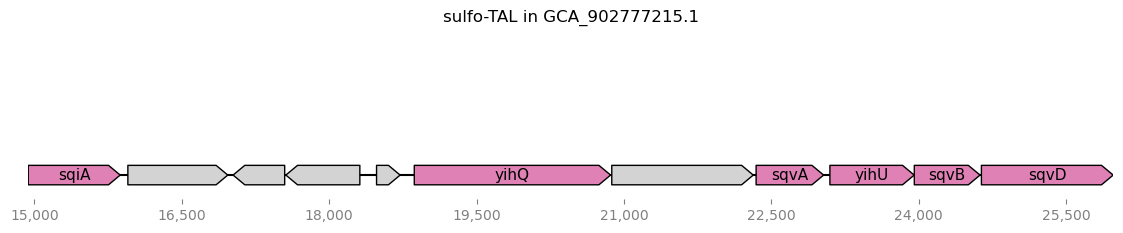

In [28]:
input_file = "../data/bakta_annotations/GCA_902777215.1_annot/GCA_902777215.1.gff3"
cluster_number = 14468
visualize_path(input_file, cluster_number, df_clusters=df_tal, candidates_df=candidates_df, 
               pathway='sulfo-TAL', color_map=color_map, genome_id='GCA_902777215.1')

### Sulfo-TK

In [29]:
df_tk = df[(df["SQ_score"].isin(["min_up", "min_down", "max"])) & (df["SQ_pathway"] == "sulfo-TK")].copy()

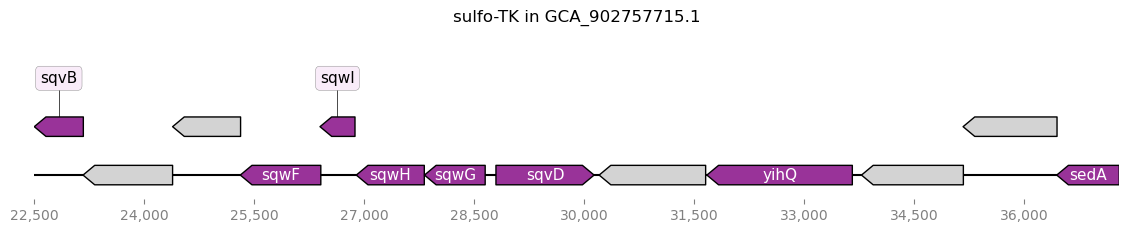

In [30]:
input_file = "../data/bakta_annotations/GCA_902757715.1_annot/GCA_902757715.1.gff3"
cluster_number = 1719
visualize_path(input_file, cluster_number, df_clusters=df_tk, candidates_df=candidates_df, 
               pathway='sulfo-TK', color_map=color_map, genome_id='GCA_902757715.1')